# College.csv — seis problemas de una regresión

Se ajusta una regresión OLS con `LinearRegression` de sklearn:

- Variable dependiente: `Grad.Rate`.
- Variables independientes: todos los demás factores.

El objetivo es únicamente **identificar de manera sencilla** si aparecen estos problemas:

1. No linealidad.
2. Correlación entre errores.
3. Colinealidad.
4. Outliers.
5. Puntos de alto leverage (HL).
6. Heterocedasticidad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("College.csv")
df = df.rename(columns={"Unnamed: 0": "College"})

df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## Preparar y ajustar el modelo

`Private` se convierte en 1 si la universidad es privada y 0 si es pública. El nombre de la universidad sólo se conserva para identificar casos.

In [2]:
# Convertir Yes/No a 1/0.
df["Private_Yes"] = (df["Private"] == "Yes").astype(int)

y = df["Grad.Rate"]
X = df.drop(columns=["College", "Private", "Grad.Rate"])

# LinearRegression ajusta el modelo mediante OLS.
modelo = LinearRegression()
modelo.fit(X, y)

# Predicción y residuo de cada universidad.
df["Prediccion"] = modelo.predict(X)
df["Residuo"] = y - df["Prediccion"]

df[["College", "Grad.Rate", "Prediccion", "Residuo"]].head().round(2)

,College,Grad.Rate,Prediccion,Residuo
0,Abilene Christian University,60,57.26,2.74
1,Adelphi University,56,63.13,-7.13
2,Adrian College,54,67.27,-13.27
3,Agnes Scott College,59,77.02,-18.02
4,Alaska Pacific University,15,51.98,-36.98


## 1. No linealidad

Se grafican las predicciones contra los residuos. Si aparece una curva clara, existe no linealidad. Si los puntos están dispersos alrededor de cero, no se observa este problema.

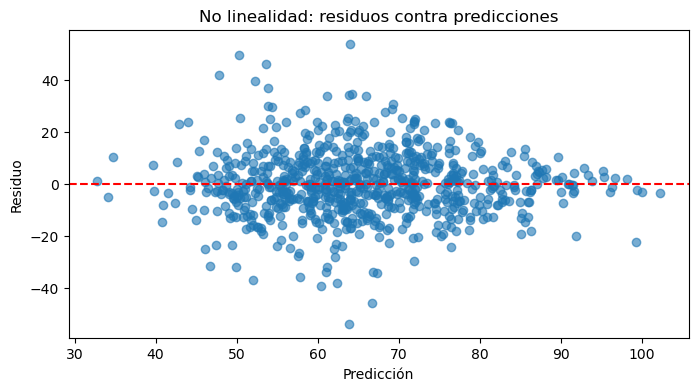

Conclusión: no se observa una curva clara; no hay evidencia visual fuerte de no linealidad.


In [3]:
plt.figure(figsize=(8, 4))
plt.scatter(df["Prediccion"], df["Residuo"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("No linealidad: residuos contra predicciones")
plt.show()

print("Conclusión: no se observa una curva clara; no hay evidencia visual fuerte de no linealidad.")

## 2. Correlación entre los errores

Se compara cada residuo con el residuo de la fila anterior. Una correlación cercana a cero indica que no siguen el mismo patrón.

In [4]:
df["Residuo_anterior"] = df["Residuo"].shift(1)

tabla_errores = df[["Residuo", "Residuo_anterior"]].corr()
tabla_errores

,Residuo,Residuo_anterior
Residuo,1.000000,-0.006299
Residuo_anterior,-0.006299,1.000000


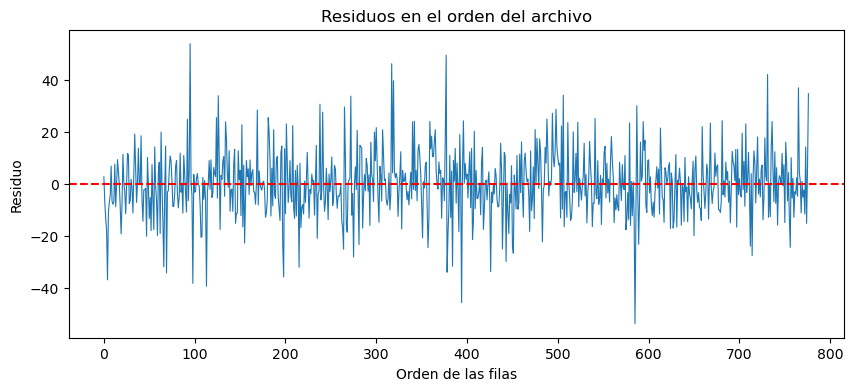

Conclusión: no se observa que los errores consecutivos sigan el mismo patrón.


In [5]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["Residuo"], linewidth=0.8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Orden de las filas")
plt.ylabel("Residuo")
plt.title("Residuos en el orden del archivo")
plt.show()

print("Conclusión: no se observa que los errores consecutivos sigan el mismo patrón.")

## 3. Colinealidad con VIF

El VIF indica si una variable independiente puede explicarse mediante las demás variables:

- VIF menor que 5: colinealidad baja.
- VIF entre 5 y 10: colinealidad moderada.
- VIF mayor que 10: colinealidad alta.

La constante se agrega para calcular correctamente el VIF, pero no se incluye en la tabla.

In [6]:
# Copia de X con una columna para el intercepto.
X_vif = X.copy()
X_vif.insert(0, "Constante", 1)

tabla_vif = pd.DataFrame()
tabla_vif["Variable"] = X.columns
tabla_vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(1, X_vif.shape[1])
]

# Clasificación sencilla para facilitar la lectura de la tabla.
def interpretar_vif(valor):
    if valor > 10:
        return "Alta"
    elif valor >= 5:
        return "Moderada"
    else:
        return "Baja"

tabla_vif["Colinealidad"] = tabla_vif["VIF"].apply(interpretar_vif)
tabla_vif = tabla_vif.sort_values("VIF", ascending=False)

tabla_vif.round(2)

,Variable,VIF,Colinealidad
2,Enroll,21.97,Alta
1,Accept,21.36,Alta
5,F.Undergrad,18.06,Alta
0,Apps,13.96,Alta
3,Top10perc,7.65,Moderada
4,Top25perc,5.66,Moderada
7,Outstate,4.21,Baja
11,PhD,4.11,Baja
12,Terminal,4.02,Baja
15,Expend,3.10,Baja


**Conclusión:** sí hay colinealidad. Las variables marcadas como `Alta` contienen información muy parecida a la proporcionada por otros factores del modelo.

## 4. Outliers

Se estandarizan los residuos para poder compararlos. Una universidad se marca como posible outlier cuando su residuo estandarizado queda fuera de `-3` y `3`.

In [7]:
p = X.shape[1] + 1  # factores más el intercepto
error_tipico = np.sqrt(np.sum(df["Residuo"] ** 2) / (len(df) - p))
df["Residuo_estandarizado"] = df["Residuo"] / error_tipico

outliers = df.loc[
    df["Residuo_estandarizado"].abs() > 3,
    ["College", "Grad.Rate", "Prediccion", "Residuo_estandarizado"]
]

outliers.round(2)

,College,Grad.Rate,Prediccion,Residuo_estandarizado
95,Cazenovia College,118,63.94,4.24
98,Centenary College,24,62.34,-3.01
113,Claflin College,21,60.43,-3.09
317,Lindenwood College,100,53.65,3.64
319,Livingstone College,92,52.23,3.12
377,Missouri Southern State College,100,50.35,3.90
394,Mount Saint Clare College,21,66.77,-3.59
585,Texas Southern University,10,63.90,-4.23
731,Webber College,90,47.82,3.31


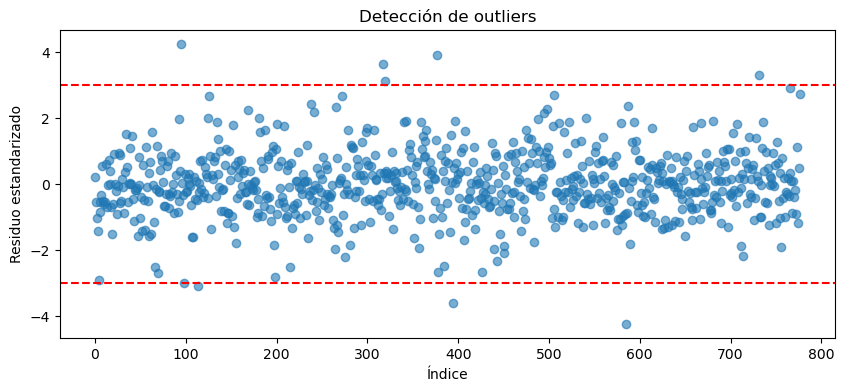

Conclusión: sí existen posibles outliers; aparecen en la tabla anterior.


In [8]:
plt.figure(figsize=(10, 4))
plt.scatter(df.index, df["Residuo_estandarizado"], alpha=0.6)
plt.axhline(3, color="red", linestyle="--")
plt.axhline(-3, color="red", linestyle="--")
plt.xlabel("Índice")
plt.ylabel("Residuo estandarizado")
plt.title("Detección de outliers")
plt.show()

print("Conclusión: sí existen posibles outliers; aparecen en la tabla anterior.")

## 5. Puntos de alto leverage (HL)

El leverage identifica universidades con combinaciones poco comunes de factores. Se calcula la matriz `H` y se muestran los casos que superan el límite sencillo `2p/n`.

In [9]:
# Agregar una columna de unos para representar el intercepto.
X_matriz = np.column_stack([np.ones(len(X)), X.to_numpy()])

# Matriz de leverage.
H = X_matriz @ np.linalg.pinv(X_matriz.T @ X_matriz) @ X_matriz.T
df["Leverage"] = np.diag(H)

limite_leverage = 2 * X_matriz.shape[1] / len(df)

alto_leverage = df.loc[
    df["Leverage"] > limite_leverage,
    ["College", "Leverage"]
].sort_values("Leverage", ascending=False)

# Se muestran los primeros casos para que la tabla no sea demasiado larga.
alto_leverage.head(10).round(3)

,College,Leverage
483,Rutgers at New Brunswick,0.451
640,University of Minnesota Twin Cities,0.357
100,Center for Creative Studies,0.210
445,Pennsylvania State Univ. Main Campus,0.179
284,Johns Hopkins University,0.173
69,Brigham Young University at Provo,0.160
20,Antioch University,0.151
250,Harvard University,0.127
513,Savannah Coll. of Art and Design,0.122
585,Texas Southern University,0.120


**Conclusión:** sí existen puntos de alto leverage; son las universidades mostradas en la tabla.

## 6. Heterocedasticidad

Existe heterocedasticidad cuando la dispersión de los residuos cambia. Para verlo fácilmente, se divide `Terminal` en cuatro grupos y se compara la desviación estándar de los residuos.

In [10]:
df["Grupo_Terminal"] = pd.qcut(
    df["Terminal"],
    4,
    labels=["Bajo", "Medio bajo", "Medio alto", "Alto"]
)

tabla_heterocedasticidad = df.groupby(
    "Grupo_Terminal", observed=False
)["Residuo"].std().to_frame("Desviación de los residuos")

tabla_heterocedasticidad.round(2)

,Desviación de los residuos
Grupo_Terminal,
Bajo,15.64
Medio bajo,12.83
Medio alto,11.09
Alto,9.82


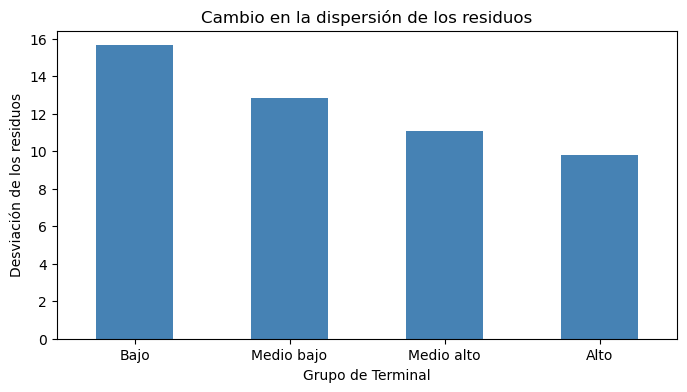

Conclusión: sí se observa heterocedasticidad porque la dispersión cambia entre grupos.


In [11]:
tabla_heterocedasticidad.plot(
    kind="bar", legend=False, color="steelblue", figsize=(8, 4)
)
plt.ylabel("Desviación de los residuos")
plt.xlabel("Grupo de Terminal")
plt.title("Cambio en la dispersión de los residuos")
plt.xticks(rotation=0)
plt.show()

print("Conclusión: sí se observa heterocedasticidad porque la dispersión cambia entre grupos.")

## Resumen final

| Problema | ¿Se observa? | Forma sencilla de identificarlo |
|---|---|---|
| No linealidad | No claramente | No aparece una curva marcada en los residuos |
| Correlación entre errores | No | Los residuos consecutivos no siguen el mismo patrón |
| Colinealidad | Sí | Algunas variables tienen VIF alto |
| Outliers | Sí | Algunos residuos estandarizados quedan fuera de ±3 |
| Puntos HL | Sí | Algunos valores de leverage superan el límite |
| Heterocedasticidad | Sí | La desviación de los residuos cambia entre grupos |

Estas reglas sirven para identificar visualmente los problemas. No se necesita medir cuánto afectan para completar este ejercicio.